<a href="https://colab.research.google.com/github/Avudai-Nayagam/DK-SOFNN/blob/main/GitHub_DKSOFNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Snippet 1: Imports & Setup
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import copy
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [ ]:
# Snippet 2: Load & Preprocess the Combined Cycle Power Plant Dataset
# Features: AT (Temperature), V (Exhaust Vacuum), AP (Ambient Pressure), RH (Relative Humidity)
# Target: PE (Net hourly electrical energy output in MW)

df = pd.read_excel('Folds5x2_pp.xlsx')
print(f"Dataset shape: {df.shape}")
print(df.head())
print(f"\n{df.describe()}")

X = df[['AT', 'V', 'AP', 'RH']].values
y = df[['PE']].values

# Train-Test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize to [0, 1]
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_norm = scaler_X.fit_transform(X_train)
X_test_norm = scaler_X.transform(X_test)
y_train_norm = scaler_y.fit_transform(y_train)
y_test_norm = scaler_y.transform(y_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_norm, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_norm, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_norm, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test_norm, dtype=torch.float32).to(device)

print(f"\nTraining samples: {X_train_t.shape[0]}")
print(f"Test samples:     {X_test_t.shape[0]}")
print(f"Input dimensions: {X_train_t.shape[1]}")

Dataset shape: (9568, 5)
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90

                AT            V           AP           RH           PE
count  9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean     19.651231    54.305804  1013.259078    73.308978   454.365009
std       7.452473    12.707893     5.938784    14.600269    17.066995
min       1.810000    25.360000   992.890000    25.560000   420.260000
25%      13.510000    41.740000  1009.100000    63.327500   439.750000
50%      20.345000    52.080000  1012.940000    74.975000   451.550000
75%      25.720000    66.540000  1017.260000    84.830000   468.430000
max      37.110000    81.560000  1033.300000   100.160000   495.760000

Training samples: 7654
Test samples:     1914
Input dimensions: 4


In [ ]:
# Snippet 3: TSK Fuzzy Rule Definition
# Each rule: IF x1 is A1 AND x2 is A2 ... THEN y = w0 + w1*x1 + w2*x2 + ...
# Antecedent: Gaussian MF  μ(x) = exp(-(x-c)² / (2σ²))
# source ∈ {'knowledge', 'data', 'compensation'} — needed for cooperative gating

class FuzzyRule:
    """
    A single TSK-type fuzzy rule.
    - centers:  (n_inputs,) Gaussian MF centers
    - widths:   (n_inputs,) Gaussian MF sigmas
    - consequent_weights: (n_inputs+1,)  [bias, w1, ..., wn]
    - source: 'knowledge' | 'data' | 'compensation'
    """
    def __init__(self, centers, widths, n_inputs, source='data'):
        self.centers = centers.clone().detach().requires_grad_(True)
        self.widths  = widths.clone().detach().requires_grad_(True)
        self.consequent_weights = torch.zeros(n_inputs + 1, device=device,
                                              requires_grad=True)
        self.source = source            # Rule origin tag
        self.activation_count = 0.0     # Running average activation
        self.age = 0                    # Epochs since creation
        self.contribution = 0.0         # Contribution to error reduction

    def firing_strength(self, X):
        """
        h_i(x) = Π_j exp(-(x_j - c_j)² / (2σ_j²))
        X: (batch, n_inputs) → returns (batch,)
        """
        diff = X - self.centers.unsqueeze(0)
        membership = torch.exp(-0.5 * (diff / (self.widths.unsqueeze(0) + 1e-8)) ** 2)
        return torch.prod(membership, dim=1)

    def consequent_output(self, X):
        """
        f_i(x) = w0 + w1·x1 + … + wn·xn
        """
        X_aug = torch.cat([torch.ones(X.shape[0], 1, device=device), X], dim=1)
        return X_aug @ self.consequent_weights

print("✅ FuzzyRule class defined (with source tagging).")

✅ FuzzyRule class defined (with source tagging).


In [ ]:
# Snippet 4: Knowledge Extraction Module
# Paper Section III-A: Extract fuzzy rules from domain knowledge
#
# For Power Plant data the domain knowledge is:
#   • Higher AT  → lower PE  (negative correlation)
#   • Higher V   → lower PE
#   • Higher AP  → slightly higher PE
#   • Higher RH  → lower PE
#
# Strategy:
#   1. Statistical profiling  → partition each feature into linguistic levels
#   2. Correlation analysis   → rank feature importance
#   3. Generate knowledge rules covering key operating regimes

class KnowledgeExtractor:
    """
    Extracts domain-knowledge fuzzy rules from data statistics
    and expert heuristics.
    """
    def __init__(self, X_train, y_train, n_inputs, feature_names=None):
        self.X = X_train.cpu().numpy() if isinstance(X_train, torch.Tensor) else X_train
        self.y = y_train.cpu().numpy().ravel() if isinstance(y_train, torch.Tensor) else y_train.ravel()
        self.n_inputs = n_inputs
        self.feature_names = feature_names or [f'x{i}' for i in range(n_inputs)]

    # ---- Step 1: Statistical profiling ----
    def _feature_profiles(self):
        """Compute per-feature statistics and correlations with target."""
        profiles = []
        for j in range(self.n_inputs):
            col = self.X[:, j]
            corr = np.corrcoef(col, self.y)[0, 1]
            profiles.append({
                'mean': col.mean(), 'std': col.std(),
                'min': col.min(),   'max': col.max(),
                'q25': np.percentile(col, 25),
                'q50': np.percentile(col, 50),
                'q75': np.percentile(col, 75),
                'corr': corr
            })
        return profiles

    # ---- Step 2: Linguistic partitioning ----
    def _linguistic_levels(self, profiles, n_levels=3):
        """
        Partition each feature into n_levels linguistic levels
        (Low / Medium / High) using quartile boundaries.
        Returns centers & widths for Gaussian MFs per level per feature.
        """
        level_params = []  # list of (centers_array, widths_array) per level
        for level_idx in range(n_levels):
            centers = np.zeros(self.n_inputs)
            widths  = np.zeros(self.n_inputs)
            for j, p in enumerate(profiles):
                if level_idx == 0:       # Low
                    centers[j] = p['q25']
                elif level_idx == 1:     # Medium
                    centers[j] = p['q50']
                else:                    # High
                    centers[j] = p['q75']
                widths[j] = max((p['q75'] - p['q25']) / (2 * n_levels), 0.05)
            level_params.append((centers, widths))
        return level_params

    # ---- Step 3: Generate knowledge rules ----
    def extract_rules(self, n_levels=3):
        """
        Generate knowledge-based fuzzy rules.
        Combines statistical profiling + correlation-based importance weighting.
        """
        profiles = self._feature_profiles()
        level_params = self._linguistic_levels(profiles, n_levels)

        # Print correlation info (domain knowledge verification)
        print("  Feature correlations with target PE:")
        for j, p in enumerate(profiles):
            direction = "↑→↓PE" if p['corr'] < 0 else "↑→↑PE"
            print(f"    {self.feature_names[j]:12s}: r = {p['corr']:+.4f}  ({direction})")

        # Create rules — one per linguistic level
        rules = []
        for level_idx, (centers, widths) in enumerate(level_params):
            c = torch.tensor(centers, dtype=torch.float32, device=device)
            w = torch.tensor(widths,  dtype=torch.float32, device=device)
            rule = FuzzyRule(c, w, self.n_inputs, source='knowledge')
            rules.append(rule)

        # Additional: K-Means enriched rules for denser coverage
        n_km = max(2, n_levels - 1)
        kmeans = KMeans(n_clusters=n_km, random_state=42, n_init=10)
        kmeans.fit(self.X)
        dist_matrix = cdist(kmeans.cluster_centers_, kmeans.cluster_centers_)
        np.fill_diagonal(dist_matrix, np.inf)
        nearest = dist_matrix.min(axis=1)

        for i in range(n_km):
            c = torch.tensor(kmeans.cluster_centers_[i], dtype=torch.float32, device=device)
            w_val = max(nearest[i] / np.sqrt(2 * n_km), 0.05)
            w = torch.full((self.n_inputs,), w_val, dtype=torch.float32, device=device)
            rule = FuzzyRule(c, w, self.n_inputs, source='knowledge')
            rules.append(rule)

        print(f"\n✅ Knowledge Extraction: {len(rules)} rules generated "
              f"({n_levels} linguistic + {n_km} cluster-based)")
        return rules, profiles

# --- Run Knowledge Extraction ---
feature_names = ['AT', 'V', 'AP', 'RH']
ke = KnowledgeExtractor(X_train_t, y_train_t, n_inputs=4, feature_names=feature_names)
knowledge_rules, feature_profiles = ke.extract_rules(n_levels=3)

for i, r in enumerate(knowledge_rules):
    print(f"  Rule {i+1} [{r.source:11s}]: center={r.centers.data.cpu().numpy().round(3)}, "
          f"width={r.widths.data.cpu().numpy().round(3)}")

  Feature correlations with target PE:
    AT          : r = -0.9479  (↑→↓PE)
    V           : r = -0.8695  (↑→↓PE)
    AP          : r = +0.5187  (↑→↑PE)
    RH          : r = +0.3897  (↑→↑PE)

✅ Knowledge Extraction: 5 rules generated (3 linguistic + 2 cluster-based)
  Rule 1 [knowledge  ]: center=[0.347 0.291 0.4   0.501], width=[0.06  0.074 0.05  0.05 ]
  Rule 2 [knowledge  ]: center=[0.549 0.475 0.497 0.659], width=[0.06  0.074 0.05  0.05 ]
  Rule 3 [knowledge  ]: center=[0.707 0.732 0.603 0.793], width=[0.06  0.074 0.05  0.05 ]
  Rule 4 [knowledge  ]: center=[0.709 0.704 0.444 0.553], width=[0.289 0.289 0.289 0.289]
  Rule 5 [knowledge  ]: center=[0.338 0.316 0.566 0.725], width=[0.289 0.289 0.289 0.289]


In [ ]:
# Snippet 5: DK-SOFNN Network with Data-Knowledge Cooperative Gating
# Paper Section II-B + Section III (Data-Knowledge Cooperative Mechanism)
#
# Key addition: Adaptive gate  α ∈ [0,1]  that blends:
#   y = α · y_knowledge + (1-α) · y_data + y_compensation
#
# α is computed per-sample based on relative confidence of each branch.

class DKSOFNN:
    """
    Data-Knowledge-Driven Self-Organizing Fuzzy Neural Network.
    Full implementation with cooperative gating.
    """
    def __init__(self, n_inputs, initial_rules=None):
        self.n_inputs = n_inputs
        self.rules = initial_rules if initial_rules else []

        # ---- Self-organization thresholds (Paper Section III) ----
        self.error_threshold          = 0.05   # ε_add
        self.firing_threshold         = 0.10   # h_min
        self.prune_activation_thresh  = 0.01
        self.prune_age_threshold      = 10
        self.merge_similarity_thresh  = 0.85
        self.max_rules = 30
        self.min_rules = 2

        # ---- Cooperative gating parameters ----
        # α = σ( gate_weight · (conf_K - conf_D) + gate_bias )
        self.gate_weight = torch.tensor(5.0, device=device, requires_grad=True)
        self.gate_bias   = torch.tensor(0.0, device=device, requires_grad=True)

        # ---- Adversarial learning parameters ----
        self.adv_epsilon = 0.02   # Perturbation magnitude
        self.adv_lambda  = 0.3    # Adversarial loss weight

        # ---- Tracking ----
        self.rule_count_history = []
        self.loss_history = []
        self.gate_history = []      # Track α over time

    # ---- Helper: get rules by source ----
    def _rules_by_source(self, source):
        return [r for r in self.rules if r.source == source]

    # ---- Branch output (for a subset of rules) ----
    def _branch_output(self, X, rules_subset):
        """Normalized weighted output from a subset of rules."""
        if len(rules_subset) == 0:
            return torch.zeros(X.shape[0], device=device), \
                   torch.zeros(X.shape[0], device=device)

        h_list = [r.firing_strength(X) for r in rules_subset]
        f_list = [r.consequent_output(X) for r in rules_subset]
        H = torch.stack(h_list)       # (n_rules, batch)
        F = torch.stack(f_list)
        h_sum = H.sum(dim=0) + 1e-8
        h_bar = H / h_sum.unsqueeze(0)
        output = (h_bar * F).sum(dim=0)
        confidence = h_sum / (len(rules_subset) + 1e-8)  # avg total activation
        return output, confidence

    # ---- Forward pass with cooperative gating ----
    def forward(self, X):
        """
        y = α · y_K + (1-α) · y_D + y_C

        α = sigmoid( gate_weight · (conf_K - conf_D) + gate_bias )
        where conf_K, conf_D are the average total firing strengths
        of knowledge and data branches respectively.
        """
        k_rules = self._rules_by_source('knowledge')
        d_rules = self._rules_by_source('data')
        c_rules = self._rules_by_source('compensation')

        y_k, conf_k = self._branch_output(X, k_rules)
        y_d, conf_d = self._branch_output(X, d_rules)
        y_c, _      = self._branch_output(X, c_rules)

        # Adaptive gate
        if len(k_rules) > 0 and len(d_rules) > 0:
            alpha = torch.sigmoid(
                self.gate_weight * (conf_k - conf_d) + self.gate_bias
            )  # (batch,)
            output = alpha * y_k + (1.0 - alpha) * y_d + y_c
        elif len(k_rules) > 0:
            output = y_k + y_c
            alpha = torch.ones(X.shape[0], device=device)
        elif len(d_rules) > 0:
            output = y_d + y_c
            alpha = torch.zeros(X.shape[0], device=device)
        else:
            output = y_c
            alpha = torch.zeros(X.shape[0], device=device)

        return output, alpha

    def forward_simple(self, X):
        """Convenience: returns only the output (no alpha)."""
        out, _ = self.forward(X)
        return out

    # ---- Parameter accessors ----
    def get_all_params(self):
        params = [self.gate_weight, self.gate_bias]
        for r in self.rules:
            params.extend([r.centers, r.widths, r.consequent_weights])
        return params

    def get_antecedent_params(self):
        params = []
        for r in self.rules:
            params.extend([r.centers, r.widths])
        return params

    def get_gate_params(self):
        return [self.gate_weight, self.gate_bias]

print("✅ DK-SOFNN network class defined (with cooperative gating).")
print(f"   Initial rules: {len(knowledge_rules)} "
      f"(Knowledge: {sum(1 for r in knowledge_rules if r.source=='knowledge')})")

✅ DK-SOFNN network class defined (with cooperative gating).
   Initial rules: 5 (Knowledge: 5)


In [ ]:
# Snippet 6: Rule Growing Mechanism (Data-Driven)
# Paper Section III-B: Add rule if error > threshold AND max firing < threshold

def rule_growing(model, X_batch, y_batch, y_pred):
    """
    Criterion: Add a 'data' rule when
      (1) |error| > ε_add  AND  (2) max_i h_i(x) < h_min
    """
    if len(model.rules) >= model.max_rules:
        return 0

    errors = torch.abs(y_batch.squeeze() - y_pred.detach())

    if len(model.rules) > 0:
        H = torch.stack([r.firing_strength(X_batch) for r in model.rules])
        max_h = H.max(dim=0)[0]
    else:
        max_h = torch.zeros(X_batch.shape[0], device=device)

    mask = (errors > model.error_threshold) & (max_h < model.firing_threshold)
    candidates = torch.where(mask)[0]

    if len(candidates) == 0:
        return 0

    worst = candidates[errors[candidates].argmax()]
    new_center = X_batch[worst].clone().detach()

    # Width from nearest existing rule
    if len(model.rules) > 0:
        centers_all = torch.stack([r.centers for r in model.rules])
        dists = torch.norm(centers_all - new_center.unsqueeze(0), dim=1)
        w_val = max(dists.min().item() / np.sqrt(2 * len(model.rules)), 0.05)
    else:
        w_val = 0.2

    w = torch.full((model.n_inputs,), w_val, device=device)
    model.rules.append(FuzzyRule(new_center, w, model.n_inputs, source='data'))
    return 1

print("✅ Rule growing (data-driven) defined.")

✅ Rule growing (data-driven) defined.


In [ ]:
# Snippet 7: Structural Compensation Rules
# Paper Section III (Structural Compensation):
# When BOTH knowledge and data rules cannot cover a data region,
# generate a 'compensation' rule to bridge the structural gap.
#
# Difference from data-driven growing:
#   - Triggered by joint failure of BOTH branches
#   - Width is set wider (to act as a patch across the gap)
#   - Consequent initialized via local linear fit around the failing region

def structural_compensation(model, X_batch, y_batch, y_pred):
    """
    Add compensation rules when BOTH knowledge and data branches
    produce high error AND low firing strength.
    """
    if len(model.rules) >= model.max_rules:
        return 0

    errors = torch.abs(y_batch.squeeze() - y_pred.detach())
    comp_threshold = model.error_threshold * 1.5  # Stricter threshold

    # Compute branch-specific firing strengths
    k_rules = model._rules_by_source('knowledge')
    d_rules = model._rules_by_source('data')

    def max_firing(rules, X):
        if len(rules) == 0:
            return torch.zeros(X.shape[0], device=device)
        H = torch.stack([r.firing_strength(X) for r in rules])
        return H.max(dim=0)[0]

    h_k = max_firing(k_rules, X_batch)
    h_d = max_firing(d_rules, X_batch)

    # Both branches fail: high error AND both have low firing
    mask = ((errors > comp_threshold) &
            (h_k < model.firing_threshold) &
            (h_d < model.firing_threshold))
    candidates = torch.where(mask)[0]

    if len(candidates) == 0:
        return 0

    # Cluster the failing region to find the best compensation center
    if len(candidates) > 5:
        fail_X = X_batch[candidates].detach().cpu().numpy()
        fail_y = y_batch[candidates].detach().cpu().numpy().ravel()
        # Use centroid of failing samples
        center_np = fail_X.mean(axis=0)
        # Wider width to cover the gap region
        spread = fail_X.std(axis=0)
        width_np = np.maximum(spread * 1.5, 0.08)

        new_center = torch.tensor(center_np, dtype=torch.float32, device=device)
        new_width  = torch.tensor(width_np,  dtype=torch.float32, device=device)

        comp_rule = FuzzyRule(new_center, new_width, model.n_inputs, source='compensation')

        # Initialize consequent via local linear fit
        X_aug = np.column_stack([np.ones(len(fail_X)), fail_X])
        try:
            theta, _, _, _ = np.linalg.lstsq(X_aug, fail_y, rcond=None)
            comp_rule.consequent_weights = torch.tensor(
                theta, dtype=torch.float32, device=device
            ).requires_grad_(True)
        except:
            pass  # Keep zero init if lstsq fails

        model.rules.append(comp_rule)
        return 1

    return 0

print("✅ Structural compensation mechanism defined.")

✅ Structural compensation mechanism defined.


In [ ]:
# Snippet 8: Rule Pruning Mechanism
# Paper Section III: Remove rules with low activation / low contribution

def rule_pruning(model, X_train):
    """
    Prune rules with:
      1. Low average activation over training data
      2. Sufficient age (don't prune newborns)
    Respects min_rules constraint.
    """
    if len(model.rules) <= model.min_rules:
        return 0

    with torch.no_grad():
        for r in model.rules:
            h = r.firing_strength(X_train)
            r.activation_count = h.mean().item()

    keep = []
    pruned = 0
    for r in model.rules:
        if r.age < model.prune_age_threshold:
            keep.append(r)  # Too young
        elif r.activation_count < model.prune_activation_thresh:
            pruned += 1     # Inactive → prune
        else:
            keep.append(r)

    if len(keep) < model.min_rules:
        keep = sorted(model.rules, key=lambda r: -r.activation_count)[:model.min_rules]
        pruned = len(model.rules) - model.min_rules

    model.rules = keep
    return pruned

print("✅ Rule pruning mechanism defined.")

✅ Rule pruning mechanism defined.


In [ ]:
# Snippet 9: Rule Merging Mechanism
# Paper Section III-D: Merge rules with high Gaussian overlap

def compute_rule_similarity(ra, rb):
    """S = exp( -0.5 Σ_j (c_aj-c_bj)² / (σ_aj²+σ_bj²) )"""
    with torch.no_grad():
        diff = ra.centers - rb.centers
        sigma_sum = ra.widths**2 + rb.widths**2 + 1e-8
        return torch.exp(-0.5 * (diff**2 / sigma_sum).sum()).item()

def rule_merging(model):
    """Merge highly similar rules; merged rule inherits the more active source."""
    if len(model.rules) <= model.min_rules:
        return 0

    merged_idx = set()
    merges = 0

    for i in range(len(model.rules)):
        if i in merged_idx:
            continue
        for j in range(i+1, len(model.rules)):
            if j in merged_idx:
                continue
            if compute_rule_similarity(model.rules[i], model.rules[j]) > model.merge_similarity_thresh:
                ri, rj = model.rules[i], model.rules[j]
                with torch.no_grad():
                    new_c = 0.5 * (ri.centers + rj.centers)
                    new_w = torch.max(ri.widths, rj.widths)
                    new_cw = 0.5 * (ri.consequent_weights + rj.consequent_weights)
                    ri.centers = new_c.clone().detach().requires_grad_(True)
                    ri.widths  = new_w.clone().detach().requires_grad_(True)
                    ri.consequent_weights = new_cw.clone().detach().requires_grad_(True)
                    # Keep source of more active rule
                    if rj.activation_count > ri.activation_count:
                        ri.source = rj.source
                merged_idx.add(j)
                merges += 1

    model.rules = [r for idx, r in enumerate(model.rules) if idx not in merged_idx]
    return merges

print("✅ Rule merging mechanism defined.")

✅ Rule merging mechanism defined.


In [ ]:
# Snippet 10: Adversarial Incremental Learning
# Paper Section IV-B: Adversarial training for robustness
#
# Core idea:
#   1. Generate adversarial samples:  x_adv = x + ε · sign(∂L/∂x)  (FGSM-style)
#   2. Compute adversarial loss on perturbed inputs
#   3. Total loss = L_clean + λ_adv · L_adv
#   This improves generalization and robustness to input noise.

def generate_adversarial_samples(model, X, y, epsilon):
    """
    FGSM-style adversarial perturbation:
      x_adv = x + ε · sign(∂L/∂x)
    """
    X_adv = X.clone().detach().requires_grad_(True)

    y_pred, _ = model.forward(X_adv)
    loss = torch.mean((y.squeeze() - y_pred) ** 2)
    loss.backward()

    # Perturbation direction
    grad_sign = X_adv.grad.sign()
    X_adv_out = (X_adv + epsilon * grad_sign).detach()
    # Clamp to valid range [0, 1] since data is normalized
    X_adv_out = X_adv_out.clamp(0.0, 1.0)

    # Zero out any leftover grads on model params
    for r in model.rules:
        if r.centers.grad is not None: r.centers.grad.zero_()
        if r.widths.grad is not None:  r.widths.grad.zero_()
        if r.consequent_weights.grad is not None: r.consequent_weights.grad.zero_()
    if model.gate_weight.grad is not None: model.gate_weight.grad.zero_()
    if model.gate_bias.grad is not None:   model.gate_bias.grad.zero_()

    return X_adv_out


def adversarial_training_step(model, X, y, lr=0.01):
    """
    One adversarial training step:
      L_total = L_clean + λ · L_adv
    Updates antecedent params + gate params via gradient descent.
    Returns (total_loss, clean_loss, adv_loss).
    """
    # ---- Clean forward ----
    y_pred_clean, alpha = model.forward(X)
    loss_clean = torch.mean((y.squeeze() - y_pred_clean) ** 2)

    # ---- Adversarial forward ----
    X_adv = generate_adversarial_samples(model, X, y, model.adv_epsilon)
    y_pred_adv, _ = model.forward(X_adv)
    loss_adv = torch.mean((y.squeeze() - y_pred_adv) ** 2)

    # ---- Combined loss ----
    loss_total = loss_clean + model.adv_lambda * loss_adv

    # ---- Backward ----
    loss_total.backward()

    # ---- Update antecedent + gate parameters ----
    with torch.no_grad():
        for r in model.rules:
            if r.centers.grad is not None:
                r.centers -= lr * r.centers.grad
            if r.widths.grad is not None:
                r.widths -= lr * r.widths.grad
                r.widths.clamp_(min=0.01)
        # Update gate params
        if model.gate_weight.grad is not None:
            model.gate_weight -= lr * model.gate_weight.grad
        if model.gate_bias.grad is not None:
            model.gate_bias -= lr * model.gate_bias.grad

    # ---- Re-enable gradients ----
    for r in model.rules:
        r.centers = r.centers.clone().detach().requires_grad_(True)
        r.widths  = r.widths.clone().detach().requires_grad_(True)
        r.consequent_weights = r.consequent_weights.clone().detach().requires_grad_(True)
    model.gate_weight = model.gate_weight.clone().detach().requires_grad_(True)
    model.gate_bias   = model.gate_bias.clone().detach().requires_grad_(True)

    return loss_total.item(), loss_clean.item(), loss_adv.item(), alpha.mean().item()

print("✅ Adversarial incremental learning defined.")

✅ Adversarial incremental learning defined.


In [ ]:
# Snippet 11: Consequent Parameter Update via LSE
# Paper Section IV-A Phase 1: θ = (Φ^T Φ + λI)^{-1} Φ^T y

def update_consequent_params_lse(model, X, y):
    """
    Regularized Least Squares for consequent weights.
    Regression matrix Φ built from normalized firing strengths.
    """
    with torch.no_grad():
        n_samples = X.shape[0]
        n_rules = len(model.rules)
        n_in = model.n_inputs

        if n_rules == 0:
            return

        # Normalized firing strengths
        H = torch.stack([r.firing_strength(X) for r in model.rules])  # (R, N)
        h_sum = H.sum(dim=0, keepdim=True) + 1e-8
        H_bar = H / h_sum  # (R, N)

        # Augmented input [1, x1, …, xn]
        X_aug = torch.cat([torch.ones(n_samples, 1, device=device), X], dim=1)

        # Build Φ: (N, R*(n_in+1))
        Phi = torch.zeros(n_samples, n_rules * (n_in + 1), device=device)
        for i in range(n_rules):
            Phi[:, i*(n_in+1):(i+1)*(n_in+1)] = H_bar[i].unsqueeze(1) * X_aug

        # Solve: θ = (Φ^T Φ + λI)^{-1} Φ^T y
        lam = 1e-4
        A = Phi.T @ Phi + lam * torch.eye(Phi.shape[1], device=device)
        b = Phi.T @ y.squeeze()

        try:
            theta = torch.linalg.solve(A, b)
        except:
            theta = torch.linalg.lstsq(Phi, y.squeeze()).solution

        for i in range(n_rules):
            w = theta[i*(n_in+1):(i+1)*(n_in+1)]
            model.rules[i].consequent_weights = w.clone().detach().requires_grad_(True)

print("✅ LSE consequent update defined.")

✅ LSE consequent update defined.


In [ ]:
# Snippet 12: Full DK-SOFNN Training Loop — Algorithm 1 from the Paper
# Phase 1: LSE for consequent params
# Phase 2: Adversarial incremental learning for antecedent + gate params
# Phase 3: Self-organization (grow / compensate / prune / merge)

def train_dk_sofnn(model, X_train, y_train, X_test, y_test,
                   n_epochs=150, batch_size=512, lr=0.005,
                   self_org_interval=5, verbose=True):

    train_losses, test_losses = [], []
    clean_losses, adv_losses  = [], []
    rule_counts, gate_values  = [], []
    n_samples = X_train.shape[0]

    print("=" * 75)
    print("  DK-SOFNN Training  (Data-Knowledge Cooperative + Adversarial)")
    print(f"  Rules: {len(model.rules)} | Epochs: {n_epochs} | "
          f"Batch: {batch_size} | LR: {lr} | ε_adv: {model.adv_epsilon}")
    print("=" * 75)

    for epoch in range(1, n_epochs + 1):
        for r in model.rules:
            r.age += 1

        idx = torch.randperm(n_samples)
        ep_total, ep_clean, ep_adv, ep_alpha = 0, 0, 0, 0
        n_batches = 0

        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            bi = idx[start:end]
            Xb, yb = X_train[bi], y_train[bi]

            # Phase 1: LSE for consequent
            update_consequent_params_lse(model, Xb, yb)

            # Phase 2: Adversarial incremental learning for antecedent + gate
            lt, lc, la, al = adversarial_training_step(model, Xb, yb, lr=lr)
            ep_total += lt; ep_clean += lc; ep_adv += la; ep_alpha += al
            n_batches += 1

        avg_total = ep_total / n_batches
        avg_clean = ep_clean / n_batches
        avg_adv   = ep_adv   / n_batches
        avg_alpha = ep_alpha / n_batches

        train_losses.append(avg_total)
        clean_losses.append(avg_clean)
        adv_losses.append(avg_adv)
        gate_values.append(avg_alpha)

        # ---- Self-Organization ----
        added = pruned = merged = compensated = 0
        if epoch % self_org_interval == 0:
            with torch.no_grad():
                y_pred_so = model.forward_simple(X_train)

            added       = rule_growing(model, X_train, y_train, y_pred_so)
            compensated = structural_compensation(model, X_train, y_train, y_pred_so)
            pruned      = rule_pruning(model, X_train)
            merged      = rule_merging(model)

        # ---- Test evaluation ----
        with torch.no_grad():
            y_pred_test = model.forward_simple(X_test)
            test_loss = torch.mean((y_test.squeeze() - y_pred_test) ** 2).item()
        test_losses.append(test_loss)
        rule_counts.append(len(model.rules))

        # ---- Log ----
        if verbose and (epoch % 10 == 0 or epoch == 1):
            n_k = sum(1 for r in model.rules if r.source == 'knowledge')
            n_d = sum(1 for r in model.rules if r.source == 'data')
            n_c = sum(1 for r in model.rules if r.source == 'compensation')
            so = ""
            if epoch % self_org_interval == 0:
                so = (f" | SO: +{added}d +{compensated}c -{pruned}p ~{merged}m")
            print(f"Ep {epoch:4d} | L_total:{avg_total:.5f} L_clean:{avg_clean:.5f} "
                  f"L_adv:{avg_adv:.5f} | Test:{test_loss:.5f} | "
                  f"Rules:{len(model.rules)}(K{n_k}/D{n_d}/C{n_c}) α:{avg_alpha:.3f}{so}")

    print("=" * 75)
    n_k = sum(1 for r in model.rules if r.source == 'knowledge')
    n_d = sum(1 for r in model.rules if r.source == 'data')
    n_c = sum(1 for r in model.rules if r.source == 'compensation')
    print(f"  Training complete. Final: {len(model.rules)} rules "
          f"(Knowledge:{n_k} | Data:{n_d} | Compensation:{n_c})")
    print("=" * 75)

    history = {
        'train_loss': train_losses, 'test_loss': test_losses,
        'clean_loss': clean_losses, 'adv_loss': adv_losses,
        'rule_counts': rule_counts, 'gate_values': gate_values
    }
    return history

# ---- Build & Train ----
model = DKSOFNN(n_inputs=4, initial_rules=knowledge_rules)
history = train_dk_sofnn(
    model, X_train_t, y_train_t, X_test_t, y_test_t,
    n_epochs=150, batch_size=512, lr=0.005,
    self_org_interval=5, verbose=True
)

  DK-SOFNN Training  (Data-Knowledge Cooperative + Adversarial)
  Rules: 5 | Epochs: 150 | Batch: 512 | LR: 0.005 | ε_adv: 0.02
Ep    1 | L_total:0.00480 L_clean:0.00306 L_adv:0.00580 | Test:0.00312 | Rules:5(K5/D0/C0) α:1.000
Ep   10 | L_total:0.04068 L_clean:0.02962 L_adv:0.03684 | Test:0.00831 | Rules:4(K2/D2/C0) α:0.675 | SO: +1d +0c -3p ~0m
Ep   20 | L_total:0.00799 L_clean:0.00528 L_adv:0.00903 | Test:0.00695 | Rules:3(K2/D1/C0) α:0.866 | SO: +0d +0c -1p ~0m
Ep   30 | L_total:0.00533 L_clean:0.00345 L_adv:0.00627 | Test:0.00337 | Rules:4(K2/D2/C0) α:0.850 | SO: +0d +0c -0p ~0m
Ep   40 | L_total:0.00564 L_clean:0.00365 L_adv:0.00661 | Test:0.00353 | Rules:4(K2/D2/C0) α:0.850 | SO: +0d +0c -0p ~0m
Ep   50 | L_total:0.00577 L_clean:0.00376 L_adv:0.00671 | Test:0.00771 | Rules:4(K2/D2/C0) α:0.851 | SO: +0d +0c -0p ~0m
Ep   60 | L_total:0.00581 L_clean:0.00378 L_adv:0.00676 | Test:0.00353 | Rules:4(K2/D2/C0) α:0.852 | SO: +0d +0c -0p ~0m
Ep   70 | L_total:0.00553 L_clean:0.00358 L_adv

In [ ]:
# Snippet 13: Evaluation Metrics (Paper Section V)

with torch.no_grad():
    y_pred_test_n  = model.forward_simple(X_test_t).cpu().numpy().reshape(-1,1)
    y_pred_train_n = model.forward_simple(X_train_t).cpu().numpy().reshape(-1,1)

y_pred_test_orig  = scaler_y.inverse_transform(y_pred_test_n)
y_pred_train_orig = scaler_y.inverse_transform(y_pred_train_n)
y_test_orig  = scaler_y.inverse_transform(y_test_norm)
y_train_orig = scaler_y.inverse_transform(y_train_norm)

metrics = {}
for split, yt, yp in [('Test', y_test_orig, y_pred_test_orig),
                       ('Train', y_train_orig, y_pred_train_orig)]:
    metrics[split] = {
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
        'MAE':  mean_absolute_error(yt, yp),
        'R²':   r2_score(yt, yp),
        'MAPE': np.mean(np.abs((yt - yp) / yt)) * 100
    }

n_k = sum(1 for r in model.rules if r.source == 'knowledge')
n_d = sum(1 for r in model.rules if r.source == 'data')
n_c = sum(1 for r in model.rules if r.source == 'compensation')

print("=" * 55)
print("  DK-SOFNN — Performance Summary")
print("=" * 55)
print(f"  {'Metric':<10} {'Train':>12} {'Test':>12}")
print("-" * 55)
for m in ['RMSE', 'MAE', 'R²', 'MAPE']:
    unit = ' MW' if m in ['RMSE','MAE'] else (' %' if m == 'MAPE' else '')
    print(f"  {m:<10} {metrics['Train'][m]:>12.4f}{unit:3s} {metrics['Test'][m]:>12.4f}{unit}")
print("-" * 55)
print(f"  Rules: {len(model.rules)} total  "
      f"(Knowledge:{n_k} | Data:{n_d} | Compensation:{n_c})")
print("=" * 55)

  DK-SOFNN — Performance Summary
  Metric            Train         Test
-------------------------------------------------------
  RMSE             4.5866 MW       4.4727 MW
  MAE              3.6479 MW       3.5612 MW
  R²               0.9278          0.9310
  MAPE             0.8037 %        0.7850 %
-------------------------------------------------------
  Rules: 4 total  (Knowledge:2 | Data:2 | Compensation:0)


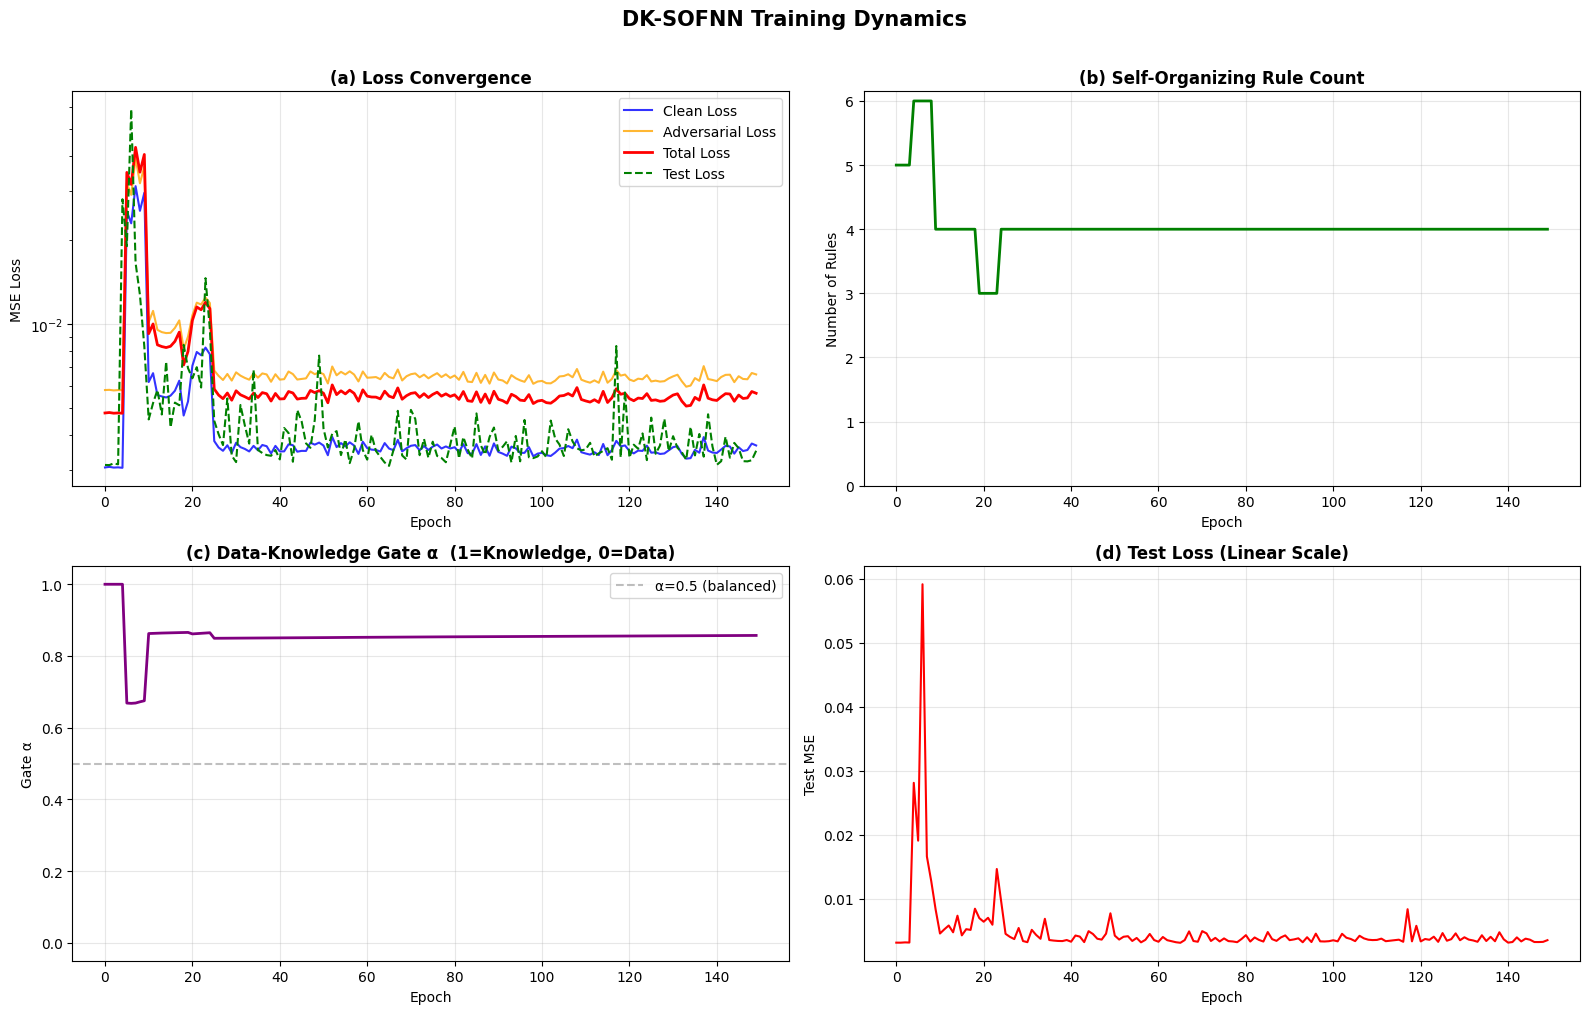

In [ ]:
# Snippet 14: Training Convergence Plots (4-panel)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Total loss convergence
axes[0,0].plot(history['clean_loss'], label='Clean Loss', color='blue', alpha=0.8)
axes[0,0].plot(history['adv_loss'],   label='Adversarial Loss', color='orange', alpha=0.8)
axes[0,0].plot(history['train_loss'], label='Total Loss', color='red', linewidth=2)
axes[0,0].plot(history['test_loss'],  label='Test Loss', color='green', linestyle='--')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('MSE Loss')
axes[0,0].set_title('(a) Loss Convergence', fontweight='bold')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3); axes[0,0].set_yscale('log')

# (b) Rule count evolution
axes[0,1].plot(history['rule_counts'], color='green', linewidth=2)
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Number of Rules')
axes[0,1].set_title('(b) Self-Organizing Rule Count', fontweight='bold')
axes[0,1].grid(True, alpha=0.3); axes[0,1].set_ylim(bottom=0)

# (c) Gate value α (knowledge vs data balance)
axes[1,0].plot(history['gate_values'], color='purple', linewidth=2)
axes[1,0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='α=0.5 (balanced)')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Gate α')
axes[1,0].set_title('(c) Data-Knowledge Gate α  (1=Knowledge, 0=Data)', fontweight='bold')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3); axes[1,0].set_ylim(-0.05, 1.05)

# (d) Test loss (linear)
axes[1,1].plot(history['test_loss'], color='red', linewidth=1.5)
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Test MSE')
axes[1,1].set_title('(d) Test Loss (Linear Scale)', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('DK-SOFNN Training Dynamics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dk_sofnn_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

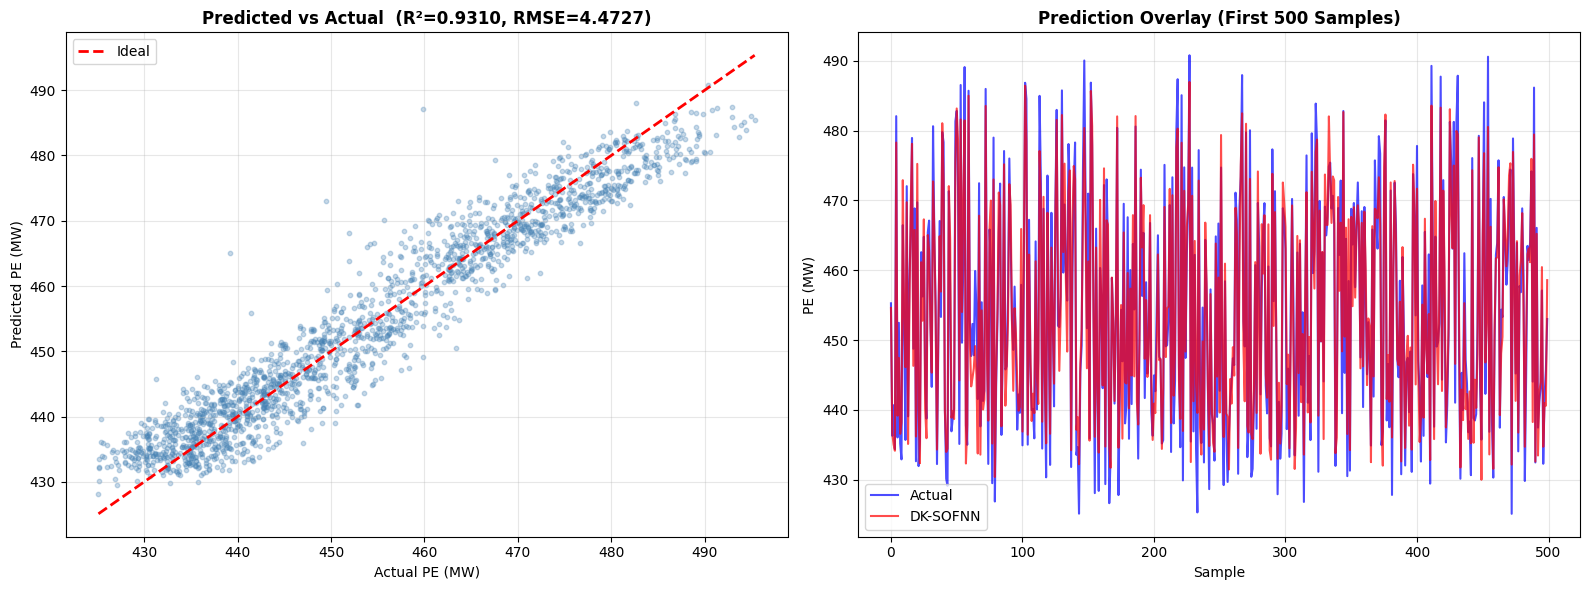

In [ ]:
# Snippet 15: Prediction vs Actual Plots

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
rmse_val = metrics['Test']['RMSE']
r2_val   = metrics['Test']['R²']
axes[0].scatter(y_test_orig, y_pred_test_orig, alpha=0.3, s=10, color='steelblue')
lo = min(y_test_orig.min(), y_pred_test_orig.min())
hi = max(y_test_orig.max(), y_pred_test_orig.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Ideal')
axes[0].set_xlabel('Actual PE (MW)'); axes[0].set_ylabel('Predicted PE (MW)')
axes[0].set_title(f'Predicted vs Actual  (R²={r2_val:.4f}, RMSE={rmse_val:.4f})', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Overlay
n_show = 500
axes[1].plot(y_test_orig[:n_show], label='Actual', color='blue', alpha=0.7)
axes[1].plot(y_pred_test_orig[:n_show], label='DK-SOFNN', color='red', alpha=0.7)
axes[1].set_xlabel('Sample'); axes[1].set_ylabel('PE (MW)')
axes[1].set_title('Prediction Overlay (First 500 Samples)', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dk_sofnn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

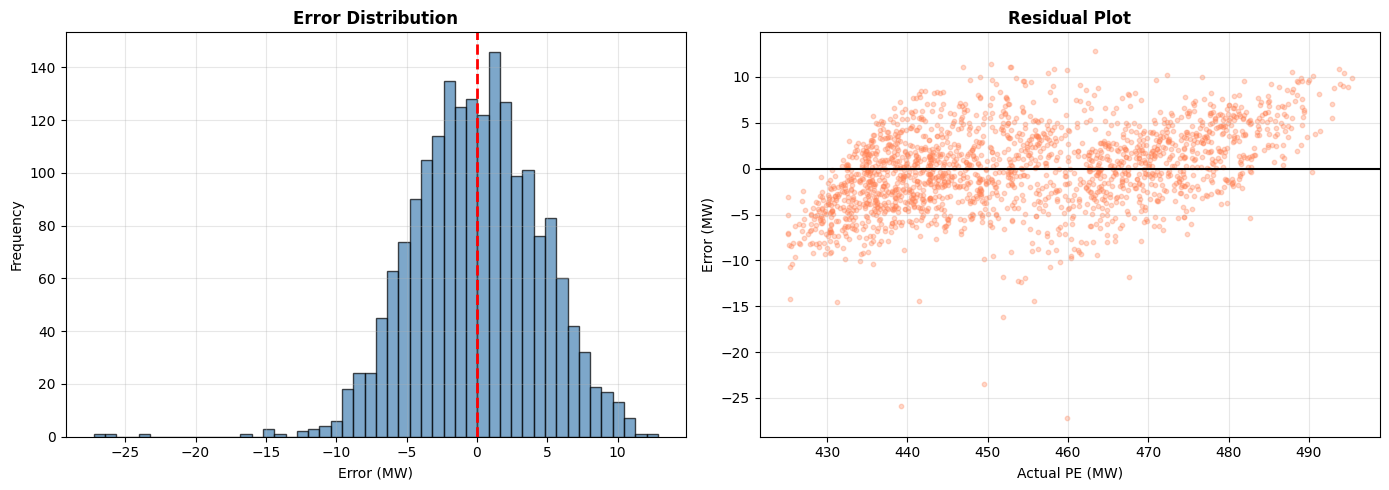

  Mean Error:  -0.0562 MW
  Std  Error:  4.4723 MW
  Max |Error|: 27.2275 MW


In [ ]:
# Snippet 16: Error Distribution & Residual Analysis

errors = y_test_orig.flatten() - y_pred_test_orig.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Error (MW)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Error Distribution', fontweight='bold'); axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test_orig, errors, alpha=0.3, s=10, color='coral')
axes[1].axhline(y=0, color='black', linestyle='-')
axes[1].set_xlabel('Actual PE (MW)'); axes[1].set_ylabel('Error (MW)')
axes[1].set_title('Residual Plot', fontweight='bold'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dk_sofnn_errors.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  Mean Error:  {np.mean(errors):.4f} MW")
print(f"  Std  Error:  {np.std(errors):.4f} MW")
print(f"  Max |Error|: {np.max(np.abs(errors)):.4f} MW")

In [ ]:
# Snippet 17: Comparison with Baselines (Paper Section V Table style)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

baselines = {
    'Linear Regression': LinearRegression(),
    'SVR (RBF)':         SVR(kernel='rbf', C=100, epsilon=0.1),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'MLP':               MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500,
                                       random_state=42, early_stopping=True),
}

results = [{
    'Model': '★ DK-SOFNN (Ours)', 'RMSE': metrics['Test']['RMSE'],
    'MAE': metrics['Test']['MAE'], 'R²': metrics['Test']['R²'],
    'MAPE (%)': metrics['Test']['MAPE'],
    'Info': f"{len(model.rules)} rules (K{n_k}/D{n_d}/C{n_c})"
}]

for name, reg in baselines.items():
    reg.fit(X_train_norm, y_train_norm.ravel())
    yp = scaler_y.inverse_transform(reg.predict(X_test_norm).reshape(-1,1))
    results.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test_orig, yp)),
        'MAE':  mean_absolute_error(y_test_orig, yp),
        'R²':   r2_score(y_test_orig, yp),
        'MAPE (%)': np.mean(np.abs((y_test_orig - yp) / y_test_orig)) * 100,
        'Info': '-'
    })

results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n" + "=" * 85)
print("  MODEL COMPARISON — Combined Cycle Power Plant Dataset")
print("=" * 85)
print(results_df.to_string(index=False, float_format='%.4f'))
print("=" * 85)


  MODEL COMPARISON — Combined Cycle Power Plant Dataset
            Model   RMSE    MAE     R²  MAPE (%)               Info
    Random Forest 3.2417 2.3284 0.9638    0.5132                  -
              MLP 4.0061 3.1287 0.9447    0.6893                  -
        SVR (RBF) 4.3322 3.5323 0.9353    0.7772                  -
★ DK-SOFNN (Ours) 4.4727 3.5612 0.9310    0.7850 4 rules (K2/D2/C0)
Linear Regression 4.5026 3.5959 0.9301    0.7933                  -


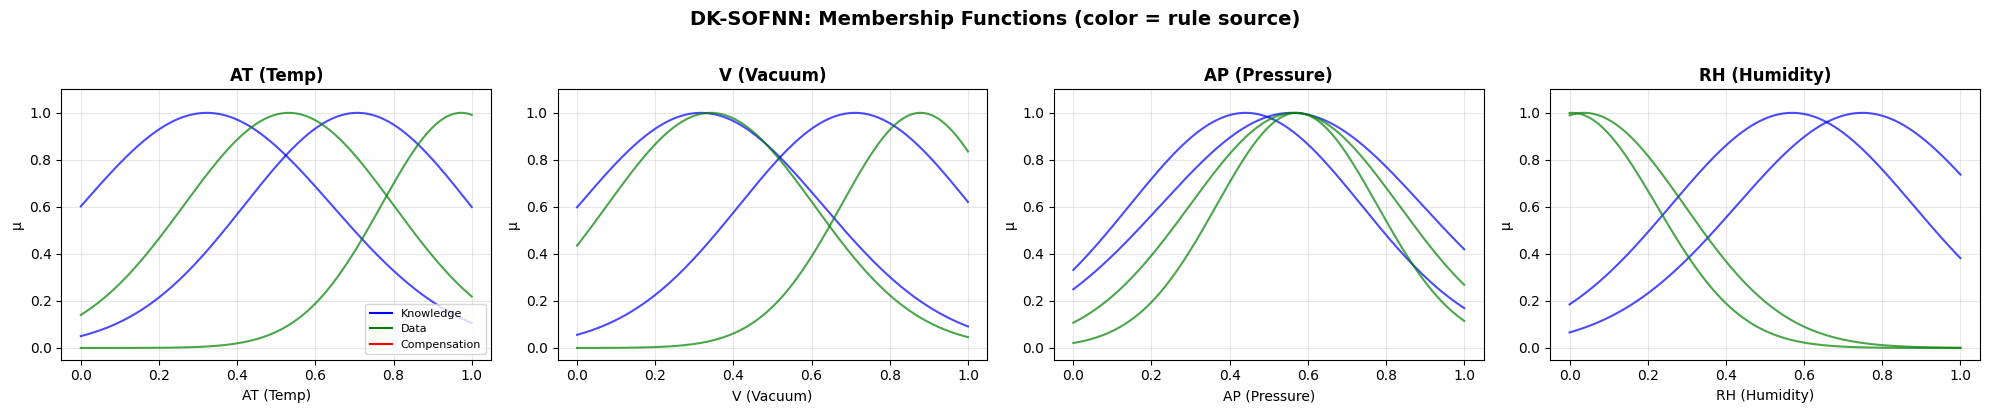

In [ ]:
# Snippet 18: Gaussian Membership Functions per Feature

feature_names = ['AT (Temp)', 'V (Vacuum)', 'AP (Pressure)', 'RH (Humidity)']
source_colors = {'knowledge': 'blue', 'data': 'green', 'compensation': 'red'}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
x_range = np.linspace(0, 1, 200)

for feat_idx in range(4):
    ax = axes[feat_idx]
    for i, rule in enumerate(model.rules):
        c = rule.centers[feat_idx].item()
        s = rule.widths[feat_idx].item()
        mu = np.exp(-0.5 * ((x_range - c) / (s + 1e-8)) ** 2)
        ax.plot(x_range, mu, color=source_colors[rule.source],
                label=f'R{i+1}({rule.source[0].upper()})', linewidth=1.5, alpha=0.7)
    ax.set_xlabel(feature_names[feat_idx]); ax.set_ylabel('μ')
    ax.set_title(feature_names[feat_idx], fontweight='bold')
    ax.set_ylim(-0.05, 1.1); ax.grid(True, alpha=0.3)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], color='blue', label='Knowledge'),
                   Line2D([0],[0], color='green', label='Data'),
                   Line2D([0],[0], color='red', label='Compensation')]
axes[0].legend(handles=legend_elements, fontsize=8)

plt.suptitle('DK-SOFNN: Membership Functions (color = rule source)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dk_sofnn_mf.png', dpi=150, bbox_inches='tight')
plt.show()

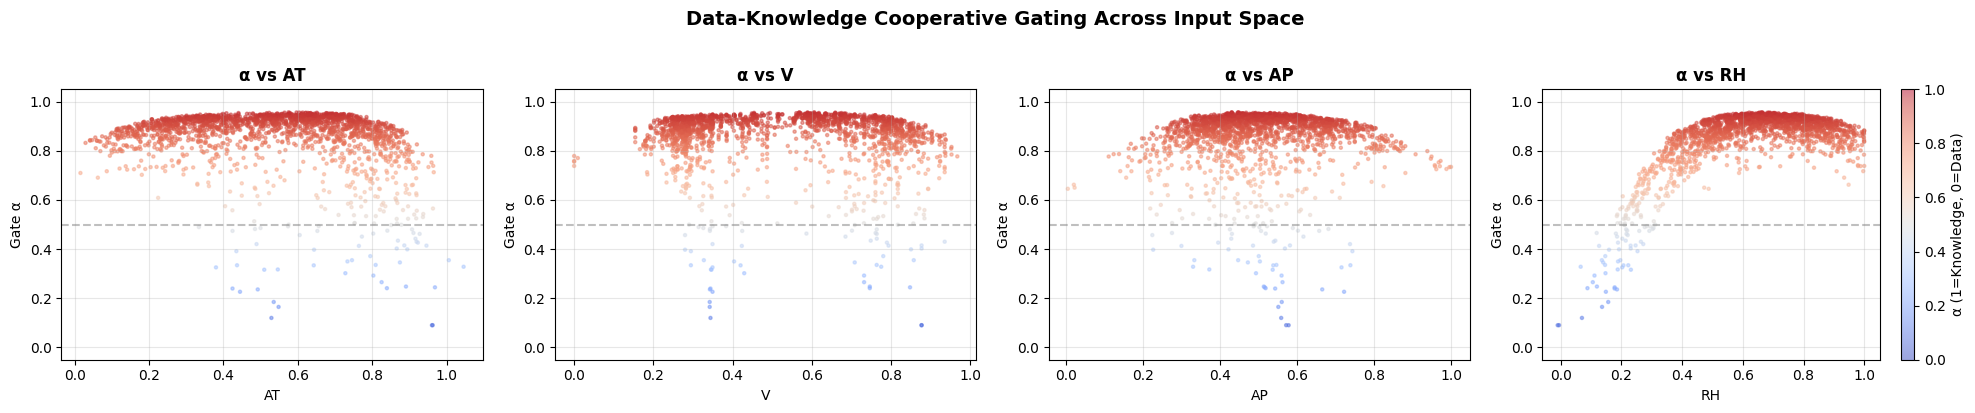


  Gate α stats: mean=0.8580, std=0.1181, min=0.0904, max=0.9565


In [ ]:
# Snippet 19: Gate Analysis — Knowledge vs Data Contribution over Input Space

with torch.no_grad():
    _, alpha_test = model.forward(X_test_t)
    alpha_np = alpha_test.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
feat_names = ['AT', 'V', 'AP', 'RH']

for j in range(4):
    ax = axes[j]
    scatter = ax.scatter(X_test_norm[:, j], alpha_np, c=alpha_np,
                         cmap='coolwarm', s=5, alpha=0.5, vmin=0, vmax=1)
    ax.set_xlabel(feat_names[j]); ax.set_ylabel('Gate α')
    ax.set_title(f'α vs {feat_names[j]}', fontweight='bold')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3)

plt.colorbar(scatter, ax=axes[-1], label='α (1=Knowledge, 0=Data)')
plt.suptitle('Data-Knowledge Cooperative Gating Across Input Space',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dk_sofnn_gate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Gate α stats: mean={alpha_np.mean():.4f}, "
      f"std={alpha_np.std():.4f}, min={alpha_np.min():.4f}, max={alpha_np.max():.4f}")

In [ ]:
# Snippet 20: Final Summary — All Extracted Fuzzy Rules

feat = ['AT', 'V', 'AP', 'RH']
source_emoji = {'knowledge': '📘', 'data': '📊', 'compensation': '🔧'}

print("=" * 75)
print("  DK-SOFNN — FINAL EXTRACTED FUZZY RULES")
print("=" * 75)
print(f"  Total rules: {len(model.rules)} "
      f"(Knowledge:{n_k}  Data:{n_d}  Compensation:{n_c})\n")

for i, r in enumerate(model.rules):
    c  = r.centers.data.cpu().numpy()
    w  = r.widths.data.cpu().numpy()
    cw = r.consequent_weights.data.cpu().numpy()

    ante = " AND ".join([f"{feat[j]}∈G({c[j]:.3f},{w[j]:.3f})" for j in range(4)])
    cons = f"{cw[0]:.4f}"
    for j in range(4):
        sign = "+" if cw[j+1] >= 0 else ""
        cons += f" {sign}{cw[j+1]:.4f}·{feat[j]}"

    print(f"  {source_emoji[r.source]} Rule {i+1} [{r.source:12s}] (age:{r.age}, act:{r.activation_count:.4f})")
    print(f"     IF   {ante}")
    print(f"     THEN PE = {cons}\n")

print("=" * 75)
print("  ✅ Implementation complete!")
print("  Paper: Data-Knowledge-Driven Self-Organizing Fuzzy Neural Network")
print("  Authors: Honggui Han, Hongxu Liu, Junfei Qiao (IEEE TNNLS, 2024)")
print("=" * 75)

  DK-SOFNN — FINAL EXTRACTED FUZZY RULES
  Total rules: 4 (Knowledge:2  Data:2  Compensation:0)

  📘 Rule 1 [knowledge   ] (age:150, act:0.4132)
     IF   AT∈G(0.707,0.289) AND V∈G(0.711,0.296) AND AP∈G(0.441,0.297) AND RH∈G(0.570,0.310)
     THEN PE = 0.6754 -0.5747·AT -0.0475·V +0.1086·AP -0.1037·RH

  📘 Rule 2 [knowledge   ] (age:150, act:0.4461)
     IF   AT∈G(0.322,0.320) AND V∈G(0.317,0.312) AND AP∈G(0.558,0.335) AND RH∈G(0.749,0.321)
     THEN PE = 1.1458 -0.8375·AT -0.1517·V -0.0747·AP -0.1325·RH

  📊 Rule 3 [data        ] (age:145, act:0.0231)
     IF   AT∈G(0.973,0.204) AND V∈G(0.879,0.203) AND AP∈G(0.572,0.206) AND RH∈G(0.007,0.216)
     THEN PE = -1.7991 +1.1409·AT +0.6762·V +0.5448·AP +0.6942·RH

  📊 Rule 4 [data        ] (age:125, act:0.0569)
     IF   AT∈G(0.532,0.268) AND V∈G(0.342,0.265) AND AP∈G(0.566,0.268) AND RH∈G(0.037,0.257)
     THEN PE = 0.4738 -0.6722·AT +0.6971·V +0.3981·AP -0.1499·RH

  ✅ Implementation complete!
  Paper: Data-Knowledge-Driven Self-Organizin